# Problem Statement= To identify Sales revenue and Profit across various regions,products and channels.Also,detecting outliers.Using these parameters we are trying to optimize pricing and promotions for market growth and safety promotion in the market area.

In [170]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
sheets = pd.read_excel(r"C:\Users\windows 10\Desktop\Regional Sales Dataset (1).xlsx",sheet_name=None)
# we use r to treat everything inside as raw text.
# sheet_name=None we use when we are working with multiple sheets.

In [178]:
#Converting each sheet to individual dataframes
df_sales=sheets['Sales Orders']
df_customers=sheets['Customers']
df_regions=sheets['Regions']
df_stateregions=sheets['State Regions']
df_products=sheets['Products']
df_budgets=sheets['2017 Budgets']

In [179]:
df_budgets.shape

(30, 2)

In [180]:
df_customers.head(5)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [181]:
df_stateregions.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [182]:
df_stateregions.shape

(49, 3)

In [183]:
new_header=df_stateregions.iloc[0]
df_stateregions.columns=new_header
df_stateregions=df_stateregions[1:].reset_index(drop=True)

df_stateregions.columns

Index(['State Code', 'State', 'Region'], dtype='object', name=0)

In [184]:
#Checking null values
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [185]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [186]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [187]:
df_stateregions.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [188]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [189]:
df_budgets.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

#Cleaning and Merging 

In [190]:
#Merging with Customers
df = df_sales.merge(
    df_customers.drop(columns=['Customer Name'], errors='ignore'),
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)


In [191]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [192]:
#Merging with Products
df = df.merge(
    df_products[['Index', 'Product Name']],
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [193]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [194]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name'],
      dtype='object')

In [195]:
#Merging with Regions
df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)


In [196]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [197]:
df_stateregions.columns

Index(['State Code', 'State', 'Region'], dtype='object', name=0)

In [198]:
#Merging with States
df=df.merge(
    df_stateregions[["State Code","Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code',
    
)

In [199]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [200]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'State Code', 'Region'],
      dtype='object')

In [201]:
#Merging with Budgets
df=df.merge(
    df_budgets,
    how='left',
    left_on='Product Name',
    right_on='Product Name'

    
)

In [202]:
df.shape

(64104, 34)

In [203]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [204]:
df.drop(columns=[
    'Customer Index',
    'Index',
    'id',
    'State Code'
], errors='ignore', inplace=True)

In [205]:
df.shape

(64104, 30)

In [206]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Names', 'Product Name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'Region', '2017 Budgets'],
      dtype='object')

In [207]:
df.shape

(64104, 30)

In [208]:
#Keeping only relevant columns and removing unnecessary columns

In [209]:
df_to_keep=[
    'OrderNumber', 'OrderDate', 'Customer Names',
    'Channel','Product Name', 'Order Quantity',
    'Unit Price', 'Line Total','Total Unit Cost',
     'state_code','county','state',
    'Region','latitude','longitude',
    '2017 Budgets'
    
    
]

In [210]:
df=df[df_to_keep]

In [211]:
df.head(5)

,OrderNumber,OrderDate,Customer Names,Channel,Product Name,Order Quantity,Unit Price,Line Total,Total Unit Cost,state_code,county,state,Region,latitude,longitude,2017 Budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [212]:
#Rename all the columns


In [213]:
df=df.rename(columns={
    'OrderNumber': 'order_number',
    'OrderDate':'order_date',
    'Customer Names':'customer_names',
    'Product Name':'product_name',
    'Order Quantity':'order_quantity',
    'Unit Price':'unit_price',
    'Line Total':'revenue',
    'Total Unit Cost':'cost',
    'state_code':'state',
    'state':'state_name',
    'latitude':'lat',
    'longitude':'long',
    '2017 Budgets':'budget'
}
)

In [214]:
df.shape

(64104, 16)

In [215]:
#Only for 2017 budget and others filling with NA values

df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

In [216]:
df.head(5)

,order_number,order_date,customer_names,Channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,Region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN


In [217]:
df

,order_number,order_date,customer_names,Channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,Region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,Bucks County,Pennsylvania,Northeast,40.15511,-74.82877,NaN
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,Cook County,Illinois,Midwest,42.11030,-88.03424,NaN
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,Broward County,Florida,South,26.24453,-80.20644,NaN
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,Erie County,New York,Northeast,42.91002,-78.74182,NaN


In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_names  64104 non-null  object        
 3   Channel         64104 non-null  object        
 4   product_name    64104 non-null  object        
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state           64104 non-null  object        
 10  county          64104 non-null  object        
 11  state_name      64104 non-null  object        
 12  Region          64104 non-null  object        
 13  lat             64104 non-null  float64       
 14  long            64104 non-null  float64       
 15  bu

In [219]:
df_2017=df[df['order_date'].dt.year==2017]

In [220]:
df_2017.head(5)

,order_number,order_date,customer_names,Channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,Region,lat,long,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


In [221]:
df.isnull().sum()

order_number          0
order_date            0
customer_names        0
Channel               0
product_name          0
order_quantity        0
unit_price            0
revenue               0
cost                  0
state                 0
county                0
state_name            0
Region                0
lat                   0
long                  0
budget            48841
dtype: int64

#Feature Engineering

In [223]:
# 1. Calculate total cost for each line item
df['total_cost'] = df['order_quantity'] * df['cost']

# 2. Calculate profit as revenue minus total_cost
df['profit'] = df['revenue'] - df['total_cost']

# 3. Calculate profit margin as a percentage
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# 4. Extract full month name from order_date for labeling (e.g., 'January', 'February')
df['order_month_name'] = df['order_date'].dt.month_name()

# 5. Extract month number from order_date for correct sorting (1–12)
df['order_month_num'] = df['order_date'].dt.month


In [224]:
df.head(5)

,order_number,order_date,customer_names,Channel,product_name,order_quantity,unit_price,revenue,cost,state,...,state_name,Region,lat,long,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1


###EDA(Exploratory Data Analysis)

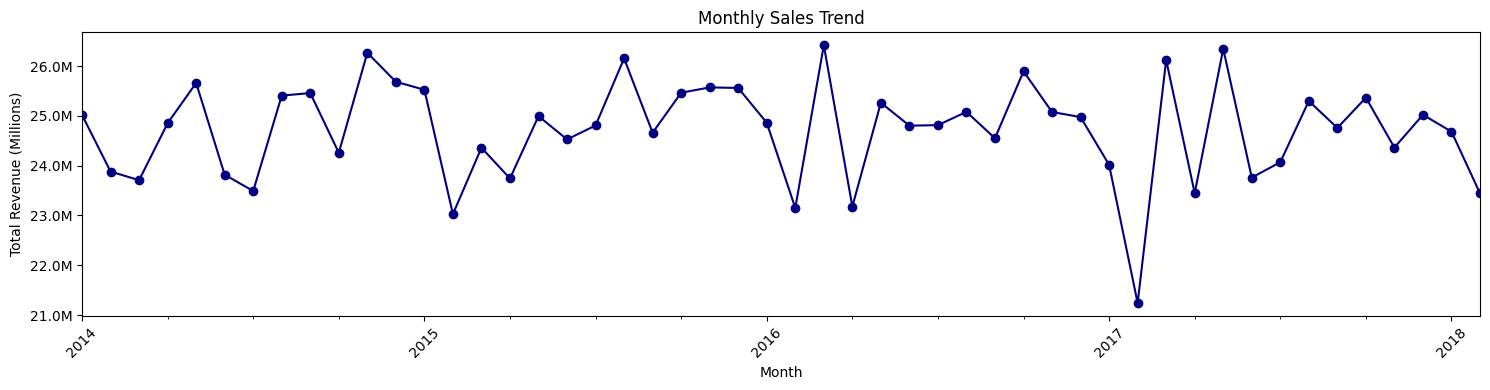

In [225]:
# Convert order_date to monthly period (e.g., 2022-01, 2022-02)
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate total revenue for each month
monthly_sales = df.groupby('order_month')['revenue'].sum()

# Set figure size for clarity
plt.figure(figsize=(15,4))

# Plot the monthly sales trend with circle markers and navy line
monthly_sales.plot(marker='o', color='navy')

# Scale y-axis values to millions for readability
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Add title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()
     

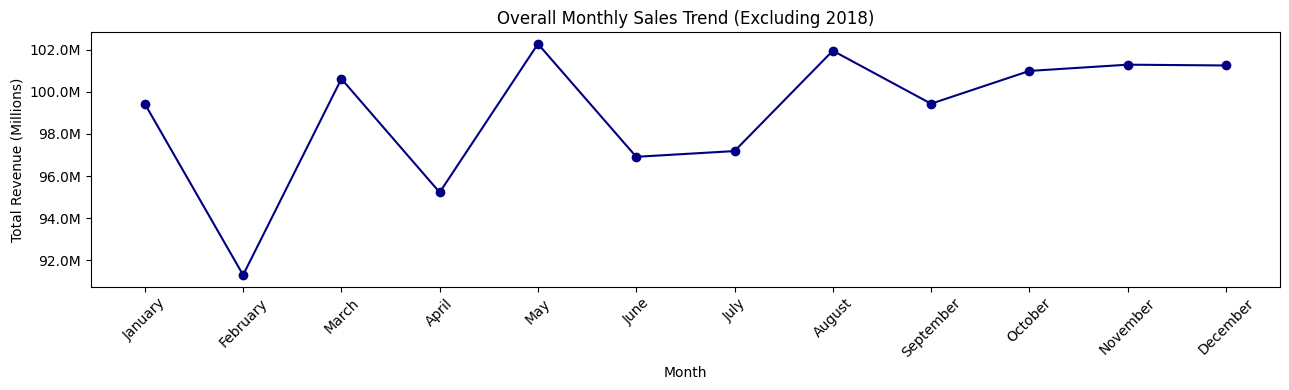

In [226]:
df['order_month_num'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
# 1. Filter out any 2018 orders
df_ = df[df['order_date'].dt.year != 2018]   # exclude any partial-year data (i.e., January and February of 2018) so that the monthly totals aren’t skewed by an incomplete year.
                                            #I create df_ so I don’t alter the original df, preserving it intact for other analyses while filtering just for this chart.


# 2. Group by month number and month name, sum revenue, then sort by month number
monthly_sales = (
    df_
    .groupby(['order_month_num', 'order_month_name'])['revenue']
    .sum()
    .sort_index()
)

# 3. Plot setup
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_sales.index.get_level_values(1),  # X-axis: month names
    monthly_sales.values,                     # Y-axis: total revenue
    marker='o',                                # circle markers
    color='navy'                               # line color
)

# 4. Scale y-axis values to millions for readability
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# 5. Add title and axis labels
plt.title('Overall Monthly Sales Trend (Excluding 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# 6. Rotate x-axis labels for readability
plt.xticks(rotation=45)

# 7. Adjust layout to prevent clipping
plt.tight_layout()

# 8. Display the plot
plt.show()


#Bar Graph for top 10 products against revenue

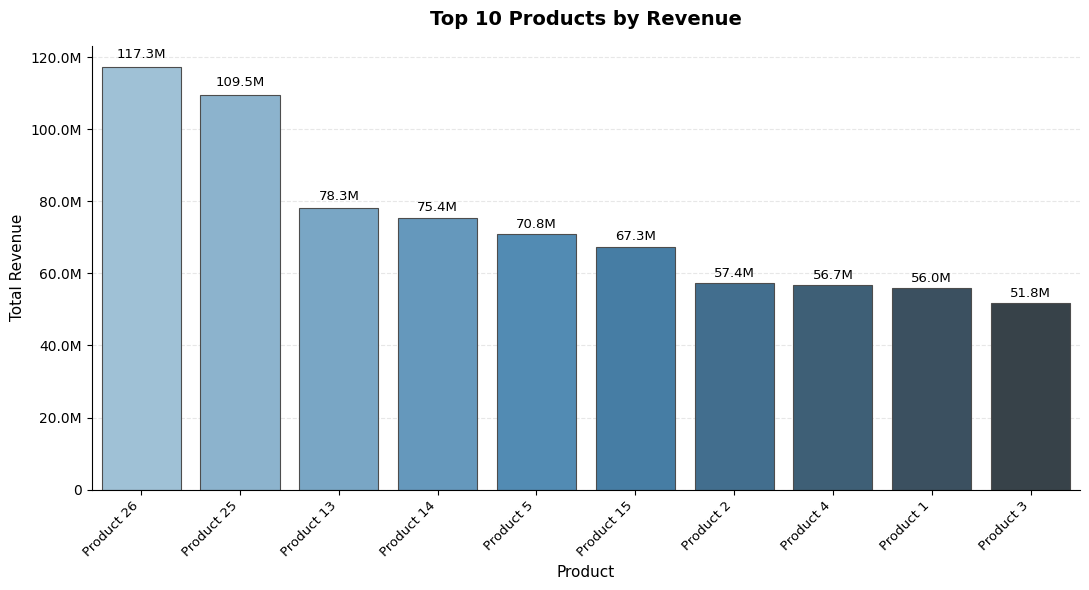

In [234]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Assumptions:
#   • DataFrame 'df' exists
#   • Columns: 'product_name' (string) and 'revenue' (numeric)
#   • Change column names below if yours are different
# ────────────────────────────────────────────────

# 1. Get top 10 products by total revenue
top10 = (
    df.groupby('product_name')['revenue']
      .sum()
      .nlargest(10)                       # top 10 highest revenue
      .reset_index()
)

# 2. Optional: shorten very long product names
top10['product_short'] = top10['product_name'].str[:30] + top10['product_name'].str[30:].apply(lambda x: '...' if x else '')

# ────────────────────────────────────────────────
#          VERTICAL BAR CHART
#    Products → x-axis    Revenue → y-axis
# ────────────────────────────────────────────────

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top10,
    x='product_short',
    y='revenue',
    hue='product_short',           # avoids palette deprecation warning
    palette='Blues_d',             # darker = higher revenue
    edgecolor='0.3',
    linewidth=0.8,
    legend=False
)

# Format y-axis (K / M)
def format_revenue(x, pos):
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x / 1_000:.0f}K'
    return f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_revenue))

# Titles & labels
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product', fontsize=11)
plt.ylabel('Total Revenue', fontsize=11)

# Add value labels on top of bars
for i, v in enumerate(top10['revenue']):
    label = f'{v:,.0f}' if v < 1_000_000 else f'{v/1_000_000:.1f}M'
    plt.text(
        i, 
        v + v * 0.015,             # slight lift above bar
        label,
        ha='center',
        va='bottom',
        fontsize=9.5
    )

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45, ha='right', fontsize=9.5)

# Clean style
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

#Bar Graph for last 10 products against revenue

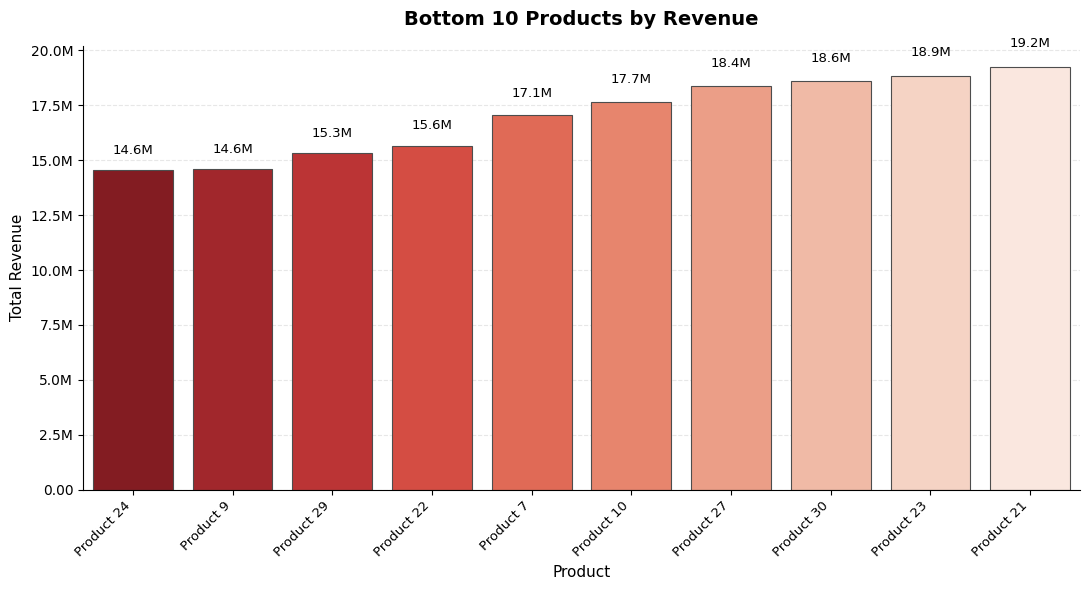

In [233]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Assumptions:
#   • DataFrame 'df' exists
#   • Columns: 'product_name' (string) and 'revenue' (numeric)
#   • Change column names below if yours are different
# ────────────────────────────────────────────────

# 1. Get bottom 10 products by total revenue
bottom10 = (
    df.groupby('product_name')['revenue']
      .sum()
      .nsmallest(10)                      # ← lowest 10 revenues
      .reset_index()
)

# 2. Optional: shorten long product names (especially useful if names are detailed)
bottom10['product_short'] = bottom10['product_name'].str[:30] + bottom10['product_name'].str[30:].apply(lambda x: '...' if x else '')

# ────────────────────────────────────────────────
#          VERTICAL BAR CHART – Bottom 10
#    Products → x-axis    Revenue → y-axis
# ────────────────────────────────────────────────

plt.figure(figsize=(11, 6))

sns.barplot(
    data=bottom10,
    x='product_short',
    y='revenue',
    hue='product_short',           # avoids palette deprecation warning
    palette='Reds_r',              # light → dark red (worse performers darker)
    edgecolor='0.3',
    linewidth=0.8,
    legend=False
)

# Format y-axis (K / M / small values)
def format_revenue(x, pos):
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x / 1_000:.0f}K'
    elif x >= 1:
        return f'{int(x)}'
    else:
        return f'{x:.2f}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_revenue))

# Titles & labels
plt.title('Bottom 10 Products by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product', fontsize=11)
plt.ylabel('Total Revenue', fontsize=11)

# Add value labels on top of bars
for i, v in enumerate(bottom10['revenue']):
    label = f'{v:,.2f}' if v < 1000 else f'{v:,.0f}'
    if v >= 1000:
        label = f'{v/1000:.1f}K' if v < 1000000 else f'{v/1000000:.1f}M'
    plt.text(
        i, 
        v + max(v * 0.04, 5 if v > 0 else 10),   # lift above bar – bigger offset for near-zero
        label,
        ha='center',
        va='bottom',
        fontsize=9.5
    )

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=9.5)

# Clean style
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

#Pie Chart for channel against revenue 

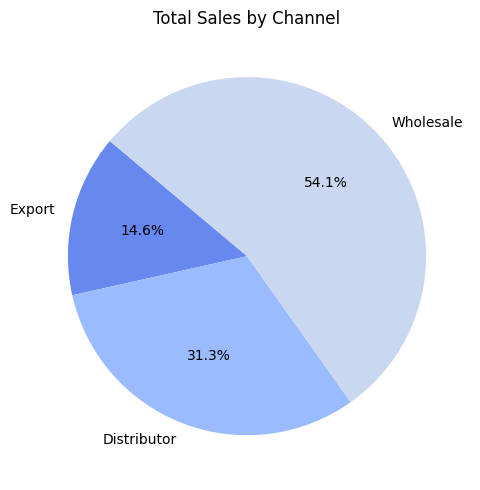

In [238]:
# Group revenue by sales channel and sort descending
chan_sales = df.groupby('Channel')['revenue'].sum().sort_values(ascending=True)

# Set figure size for the pie chart
plt.figure(figsize=(5, 5))

# Plot pie chart with percentage labels and a defined start angle
plt.pie(
    chan_sales.values,                   # Data: revenue values per channel
    labels=chan_sales.index,             # Labels: channel names
    autopct='%1.1f%%',                   # Display percentages with one decimal
    startangle=140,                      # Rotate chart so first slice starts at 140 degrees
    colors=sns.color_palette('coolwarm') # Color palette for slices
)

# Add title for context
plt.title('Total Sales by Channel')

# Adjust layout to ensure everything fits well
plt.tight_layout()

# Display the chart
plt.show()

In [240]:
#Plotting a histogram for order_number against revenue

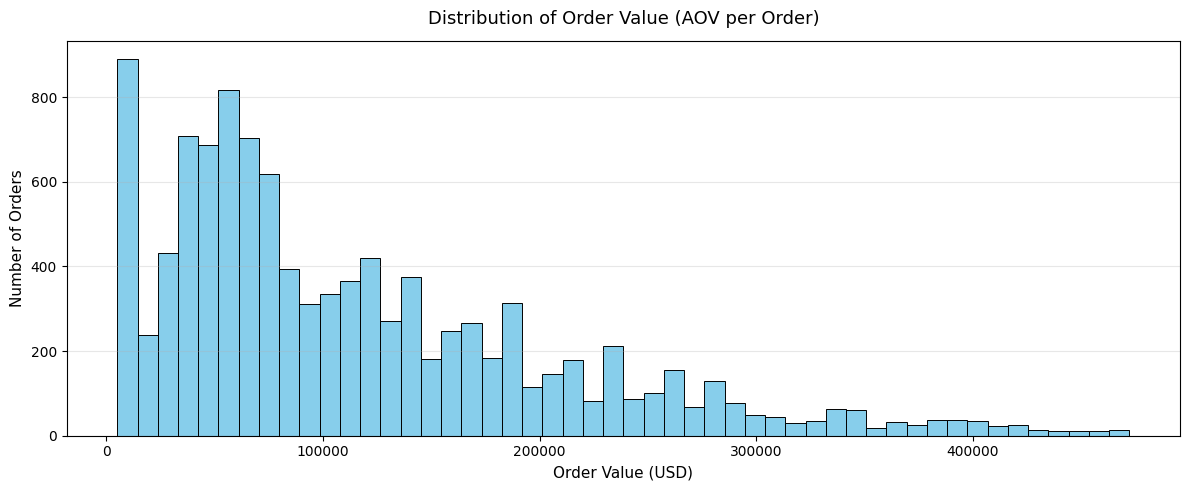

In [242]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Calculate order value (total revenue per order_number) ───
order_values = df.groupby('order_number')['revenue'].sum()

# ─── Plot ───
plt.figure(figsize=(12, 5))

plt.hist(
    order_values,
    bins=50,
    color='skyblue',
    edgecolor='black',
    linewidth=0.7
)

plt.title('Distribution of Order Value (AOV per Order)', fontsize=13, pad=12)
plt.xlabel('Order Value (USD)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [246]:
#Unit price distribution per product

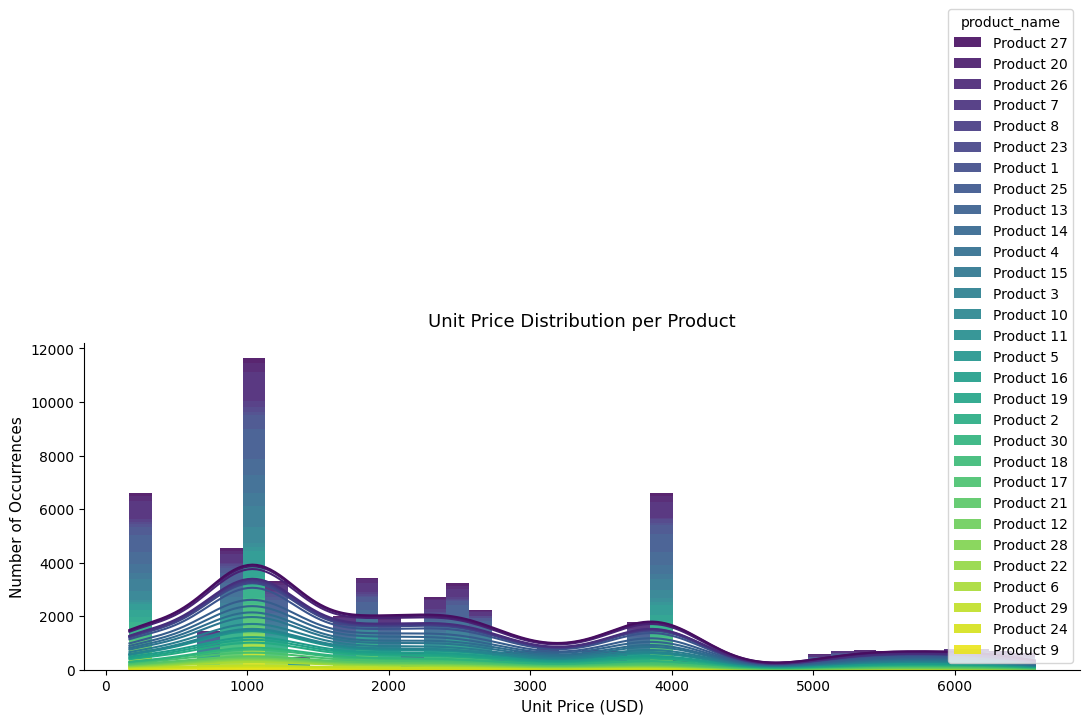

In [247]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x='unit_price',
    hue='product_name',           # or 'product_id', 'category' etc.
    multiple='stack',             # or 'dodge', 'layer', 'fill'
    bins=40,
    kde=True,
    palette='tab20' if df['product_name'].nunique() <= 20 else 'viridis',
    edgecolor='none',
    alpha=0.9,
    linewidth=0.3
)

plt.title("Unit Price Distribution per Product", fontsize=13, pad=12)
plt.xlabel("Unit Price (USD)", fontsize=11)
plt.ylabel("Number of Occurrences", fontsize=11)

# Optional: log scale if prices vary by orders of magnitude
# plt.xscale('log')
# plt.xlabel("Unit Price (USD) – log scale")

sns.despine()
plt.tight_layout()
plt.show()

#Top 10 states by revenue and order_count

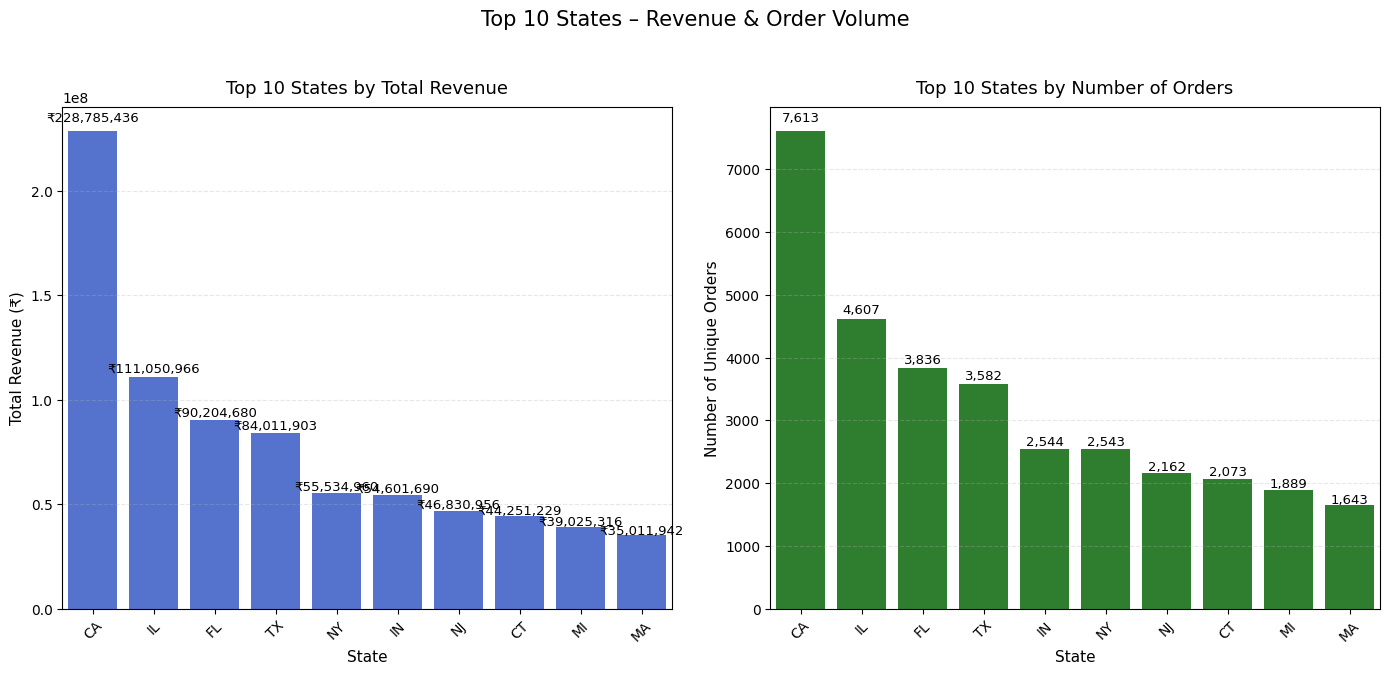

In [249]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure revenue is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Change this to match your actual column name
state_col = 'state'          # e.g. 'shipping_state', 'State', 'customer_state'

# ─── Top 10 by total revenue ───
top10_revenue = (
    df.groupby(state_col, as_index=False)['revenue']
      .sum()
      .dropna()
      .nlargest(10, 'revenue')
)

# ─── Top 10 by number of distinct orders ───
top10_orders = (
    df.groupby(state_col, as_index=False)['order_number']
      .nunique()
      .dropna()
      .nlargest(10, 'order_number')
)

# ─── Plot: vertical bars (states on x, values on y) ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), sharey=False)

# Left: Top 10 by Revenue
sns.barplot(
    data=top10_revenue,
    x=state_col,
    y='revenue',
    ax=ax1,
    color='royalblue',
)

ax1.set_title('Top 10 States by Total Revenue', fontsize=13, pad=10)
ax1.set_xlabel('State', fontsize=11)
ax1.set_ylabel('Total Revenue (₹)', fontsize=11)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on top of bars
for i, v in enumerate(top10_revenue['revenue']):
    ax1.text(i, v * 1.02, f'₹{v:,.0f}', ha='center', fontsize=9.5, fontweight='medium')

# Right: Top 10 by Order Count
sns.barplot(
    data=top10_orders,
    x=state_col,
    y='order_number',
    ax=ax2,
    color='forestgreen',
)

ax2.set_title('Top 10 States by Number of Orders', fontsize=13, pad=10)
ax2.set_xlabel('State', fontsize=11)
ax2.set_ylabel('Number of Unique Orders', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for i, v in enumerate(top10_orders['order_number']):
    ax2.text(i, v * 1.02, f'{v:,}', ha='center', fontsize=9.5, fontweight='medium')

plt.suptitle('Top 10 States – Revenue & Order Volume', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

In [250]:
#Average profit margin by channel

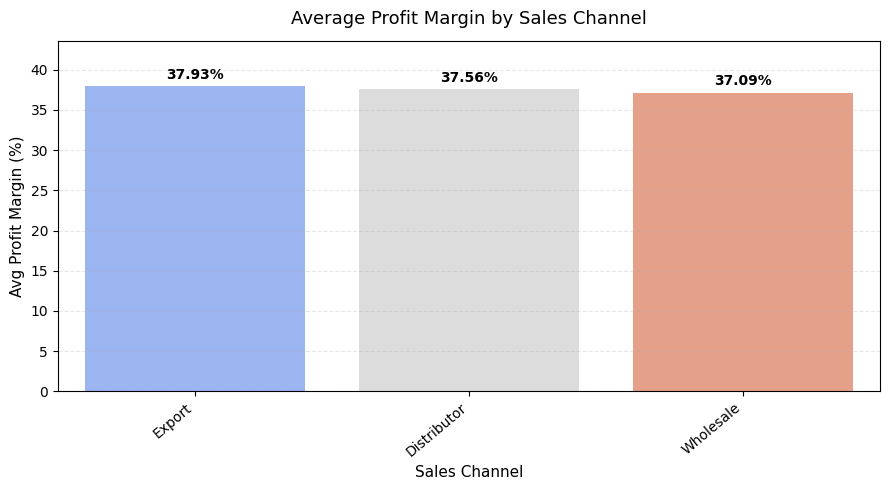

In [257]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ─── 1. Compute average profit margin % per channel ───
channel_margin = (
    df.groupby('Channel')['profit_margin_pct']
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

# ─── 2. Prepare figure ───
plt.figure(figsize=(9, 5))   # slightly wider → better readability

# ─── 3. Modern barplot without FutureWarning ───
ax = sns.barplot(
    x=channel_margin.index,
    y=channel_margin.values,
    hue=channel_margin.index,       # ← this line fixes the palette warning
    palette='coolwarm',
    dodge=False,
    legend=False                    # ← hide useless legend
)

# ─── 4. Title & labels ───
plt.title('Average Profit Margin by Sales Channel', fontsize=13, pad=12)
plt.xlabel('Sales Channel', fontsize=11)
plt.ylabel('Avg Profit Margin (%)', fontsize=11)

# ─── 5. Annotate bars with values ───
for i, v in enumerate(channel_margin.values):
    ax.text(
        x=i,
        y=v + 0.6 if v >= 0 else v - 1.8,
        s=f"{v:.2f}%",
        ha='center',
        va='bottom' if v >= 0 else 'top',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# ─── 6. Final touches ───
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, max(channel_margin.values) * 1.15)   # give headroom for labels
plt.tight_layout()
plt.show()

In [260]:
#Top 10 states against revenue and Top 10 states against number of orders

C:\Users\windows 10\AppData\Local\Temp\ipykernel_31240\1570446598.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


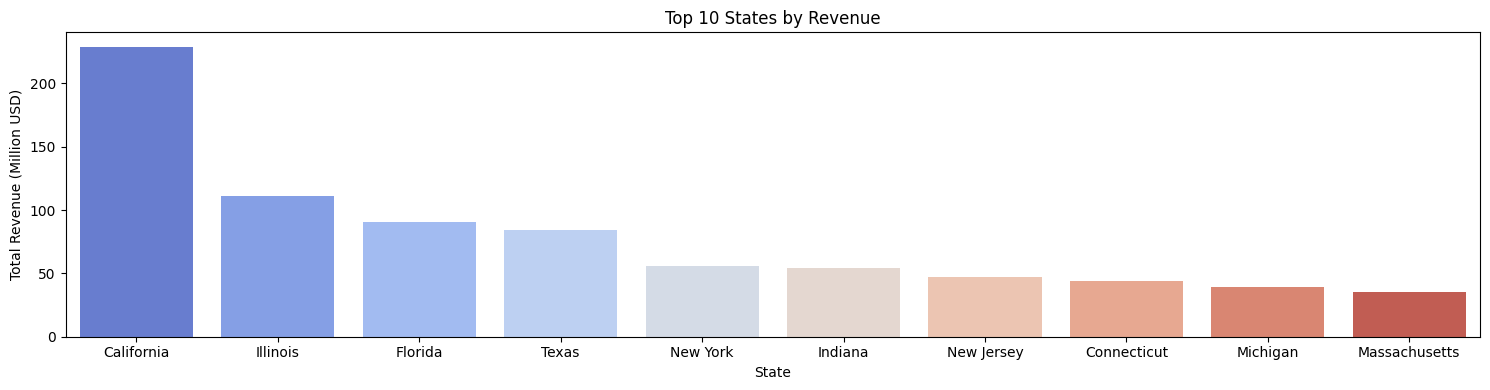

C:\Users\windows 10\AppData\Local\Temp\ipykernel_31240\1570446598.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


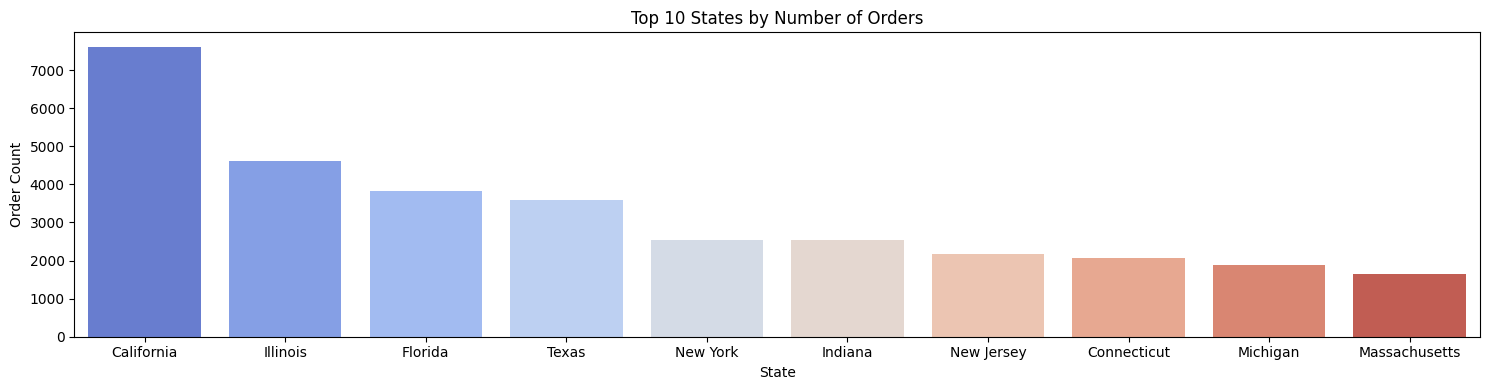

In [264]:
# Aggregate total revenue and unique order count per state
state_rev = df.groupby('state_name').agg(
    revenue=('revenue', 'sum'),          # Sum up revenue per state
    orders=('order_number', 'nunique')   # Count unique orders per state
).sort_values('revenue', ascending=False).head(10)  # Keep top 10 by revenue

# Plot 1: Top 10 states by revenue (scaled to millions)
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,                   # X-axis: state names
    y=state_rev['revenue'] / 1e6,        # Y-axis: revenue in millions
    palette='coolwarm'                   # Color palette
)
plt.title('Top 10 States by Revenue')     # Chart title
plt.xlabel('State')                       # X-axis label
plt.ylabel('Total Revenue (Million USD)') # Y-axis label
plt.tight_layout()                        # Adjust layout
plt.show()                                # Display the plot

# Plot 2: Top 10 states by number of orders
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,                   # X-axis: state names
    y=state_rev['orders'],               # Y-axis: order counts
    palette='coolwarm'                   # Color palette
)
plt.title('Top 10 States by Number of Orders')  # Chart title
plt.xlabel('State')                              # X-axis label
plt.ylabel('Order Count')                        # Y-axis label
plt.tight_layout()                               # Adjust layout
plt.show()                                       # Display the plot
     

In [265]:
#Profit Margin against Revenue

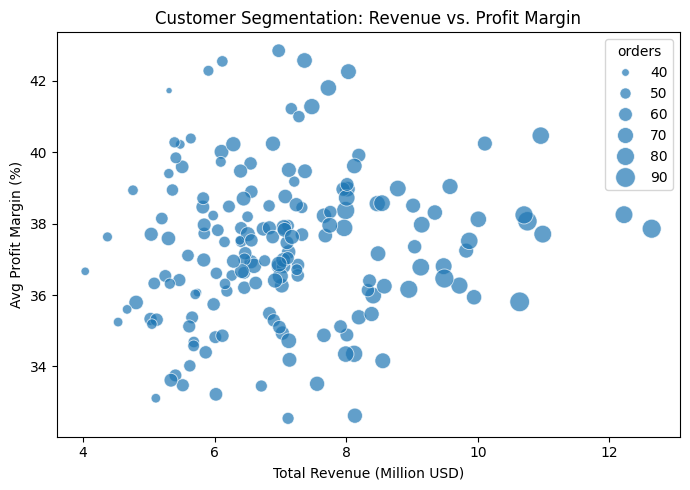

In [268]:
# Aggregate metrics per customer
cust_summary = df.groupby('customer_names').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
)

# Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

# Bubble chart with revenue in millions
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',        # <-- use revenue in millions
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')  # <-- updated label
plt.ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.show()


In [269]:
#Correlation HeatMap of Numerical Features

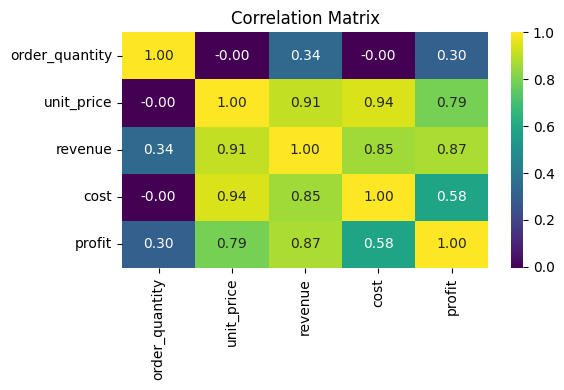

In [271]:
# List numeric columns to include in the correlation calculation
num_cols = ['order_quantity', 'unit_price', 'revenue', 'cost', 'profit']

# Calculate the correlation matrix for these numeric features
corr = df[num_cols].corr()

# Set the figure size for clarity
plt.figure(figsize=(6,4))

# Plot the heatmap with annotations and a viridis colormap
sns.heatmap(
    corr,           # Data: correlation matrix
    annot=True,     # Display the correlation coefficients on the heatmap
    fmt=".2f",      # Format numbers to two decimal places
    cmap='viridis'  # Color palette for the heatmap
)

# Add title for context
plt.title('Correlation Matrix')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the heatmap
plt.show()
     
